# YOLOv8 / Faster R-CNN Evaluation

这个 notebook 用于统一评估仓库中的 `YOLOv8` 和 `Faster R-CNN` 检测模型，支持：

- `COCO JSON` 或 `YOLO txt` 真值读取
- `mAP@0.5`、`mAP@0.5:0.95`、micro/macro `Precision / Recall / F1`
- 含背景类的检测混淆矩阵
- `PR` 曲线、每类 `AP` 条形图、阈值扫描曲线
- 计数指标：每图 `MAE / RMSE / Bias` 与 GT vs Pred 散点图

说明：默认评估类别为 `10` 类，不包含 `Actinomycetes`，因为你已经确认它不在训练集和测试集里。

In [1]:
from pathlib import Path
import sys
from IPython.display import display

DRAW_DIR = Path(r"E:\CCI-Colony Counting and Identification\CCI\draw")
if str(DRAW_DIR) not in sys.path:
    sys.path.insert(0, str(DRAW_DIR))

from evaluate_models_helper import make_default_config, run_full_evaluation, default_model_specs


c:\Users\asus-\.conda\envs\CCIF\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# =========================
# Config
# =========================

cfg = make_default_config(r"E:\CCI-Colony Counting and Identification\CCI")

# TODO: 填写测试集图片目录
cfg["test_images_dir"] = r"E:\CCI-Colony Counting and Identification\CCI\PHOTO\Test"

# 二选一: 'coco' 或 'yolo'
cfg["gt_source"] = "coco"

# TODO: 如果使用 COCO 标注，填写测试集 JSON
cfg["coco_ann_path"] = r"C:\Users\asus-\Downloads\test est\annotations\Test.json"

# TODO: 如果使用 YOLO txt 标注，填写 labels 目录
cfg["yolo_labels_dir"] = r""

# 如果你使用 YOLO txt 真值，并且 txt 中类别顺序与默认 10 类不一致，请在这里改
# cfg["yolo_gt_class_names"] = [...]

# 如需只评估部分模型，可把 enabled 改成 False
cfg["model_specs"] = default_model_specs(cfg["root"], cfg["master_class_names"])

# 如果你的 COCO categories 里还保留了不参与本次评估的类（例如 Actinomycetes），
# 保持 False 即可自动忽略；若你希望遇到这类情况直接报错，再改成 True。
# cfg["strict_gt_category_check"] = False

# 你也可以在这里微调阈值
# cfg["confusion_conf"] = 0.25
# cfg["count_conf"] = 0.25
# cfg["raw_pred_conf"] = 0.001

print("Output dir:", cfg["output_dir"])
print("Classes:", cfg["master_class_names"])


Output dir: E:\CCI-Colony Counting and Identification\CCI\draw\eval_results
Classes: ['Alternaria alternata', 'Alternaria tenuissima', 'Bacillus subtilis', 'Bacillus thaonhiensis', 'Deinococcus soli', 'Kocuria oceani', 'Arthrobacter oryzae', 'Micrococcus luteus', 'Staphylococcus aureus', 'Streptomyces spororaveus']


忽略不参与评估的 COCO 类别: ['Actinomycetes']
Loaded 10 test images from: E:\CCI-Colony Counting and Identification\CCI\PHOTO\Test
Evaluating: YOLOv8-basic


Infer YOLOv8-basic: 100%|██████████| 10/10 [00:03<00:00,  2.82it/s]


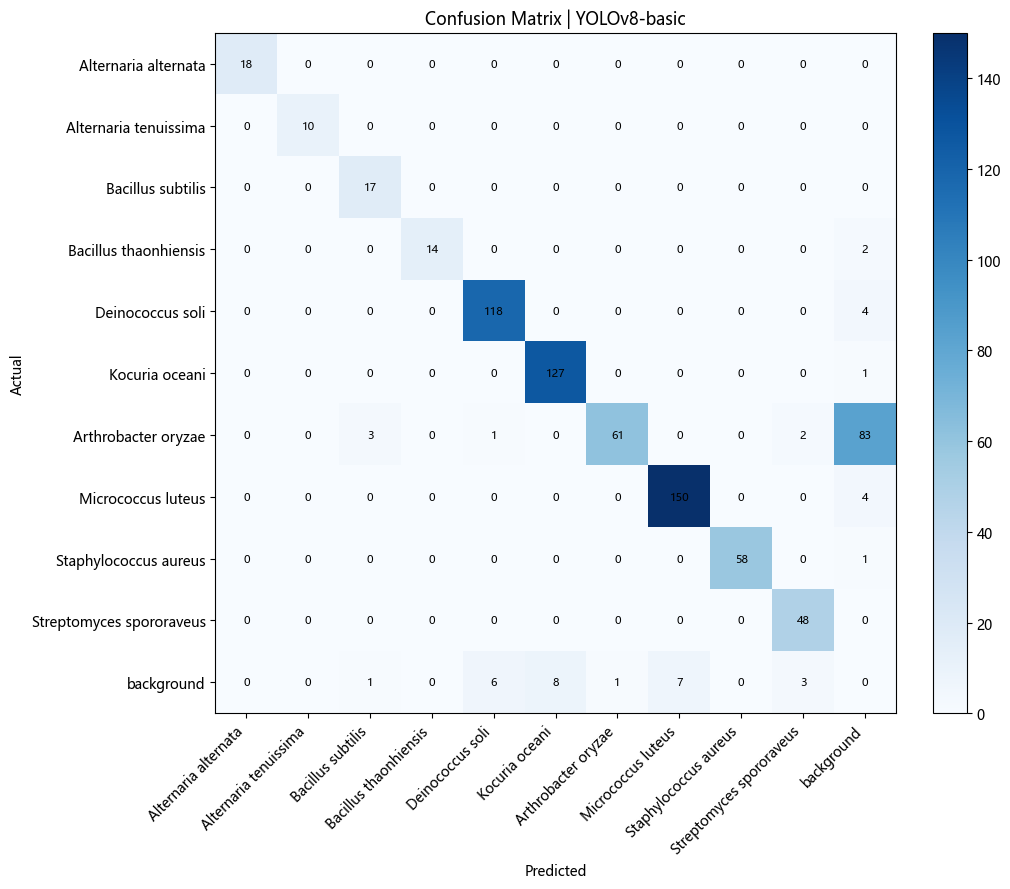

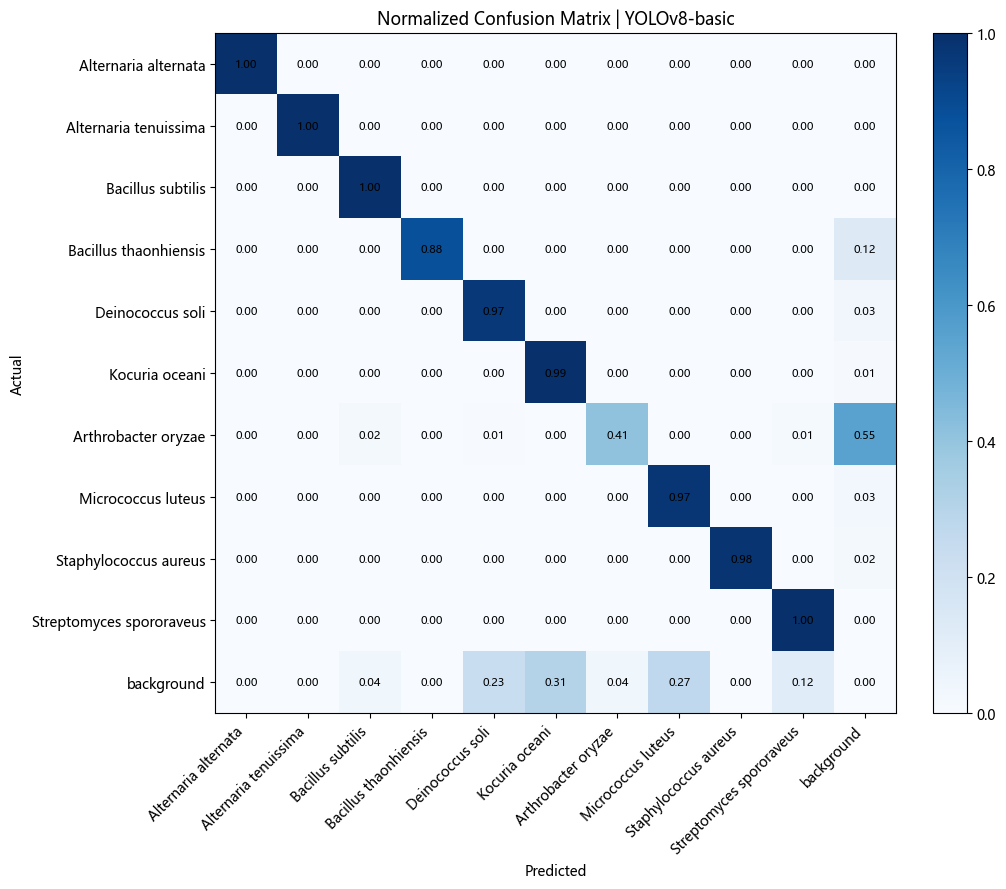

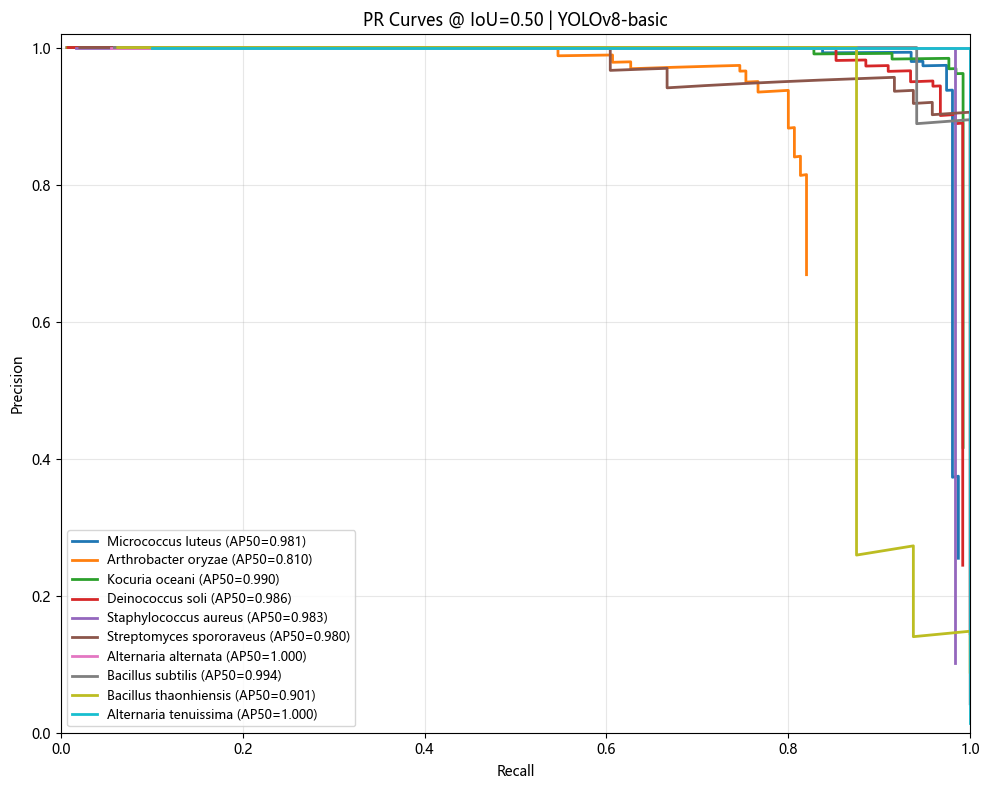

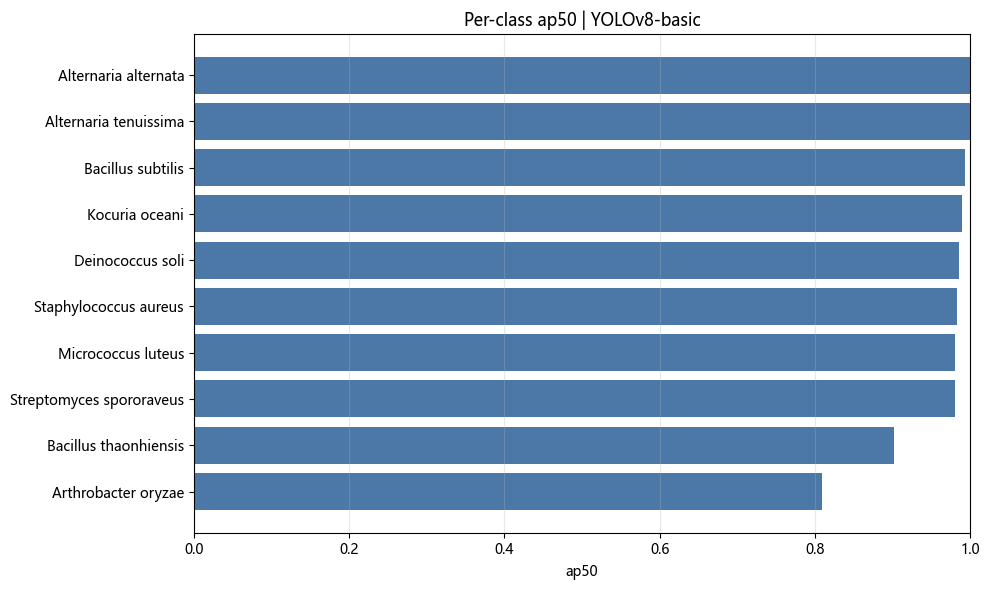

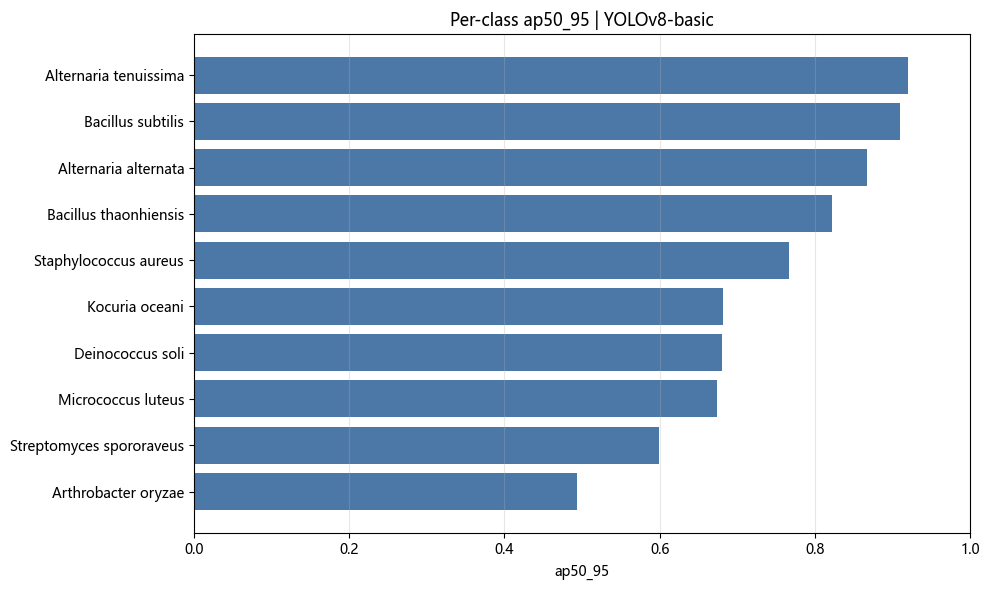

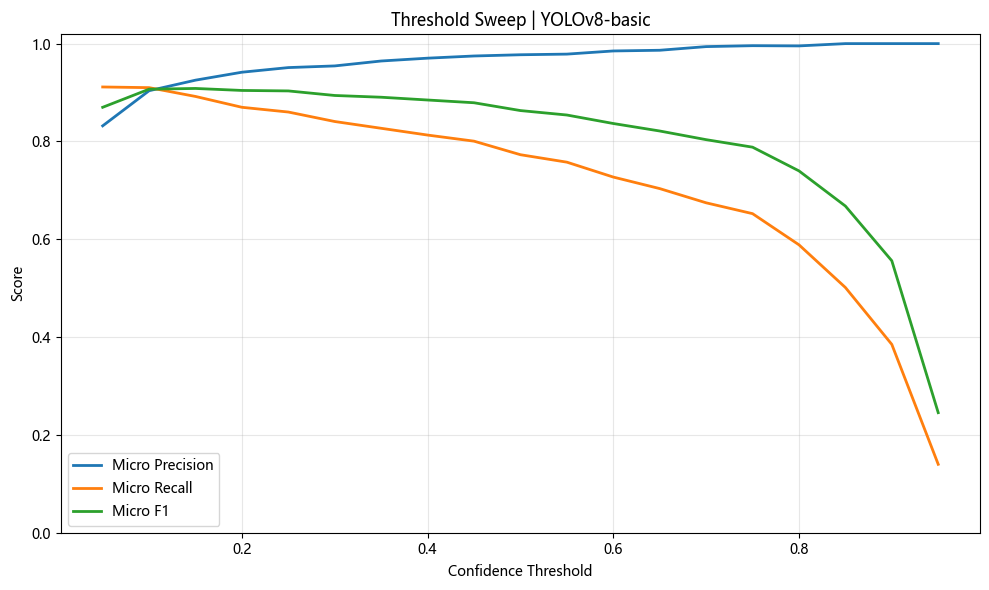

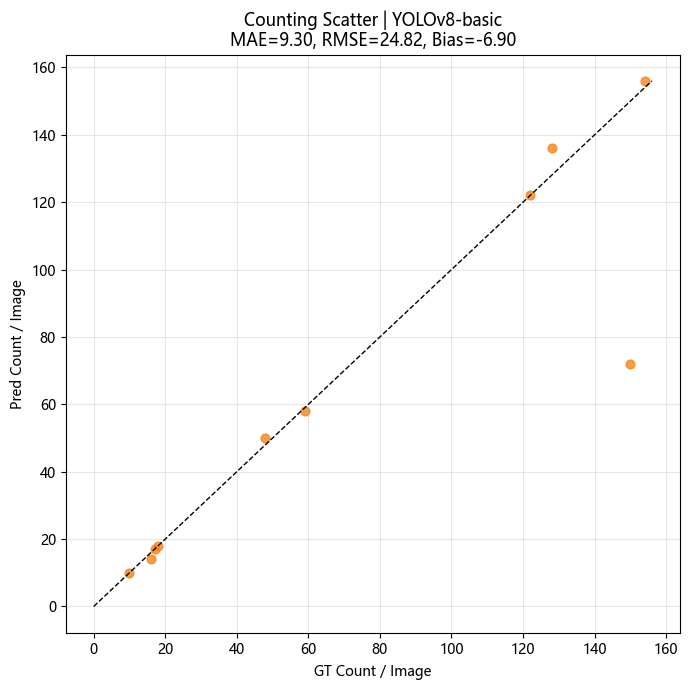

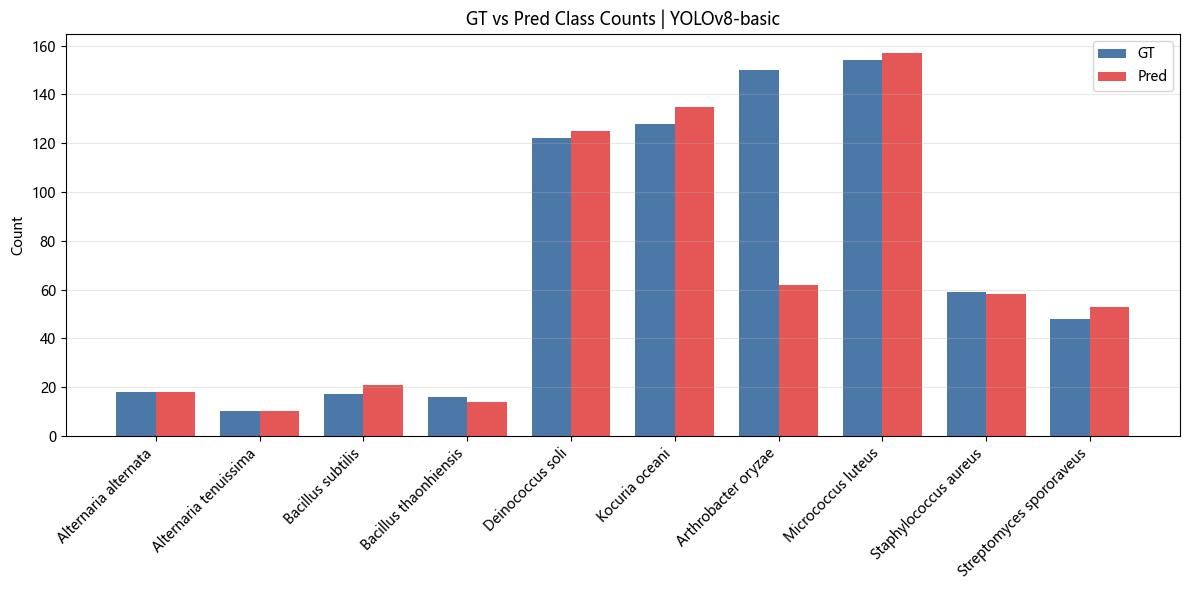

Evaluating: YOLOv8-final


Infer YOLOv8-final: 100%|██████████| 10/10 [00:01<00:00,  5.64it/s]


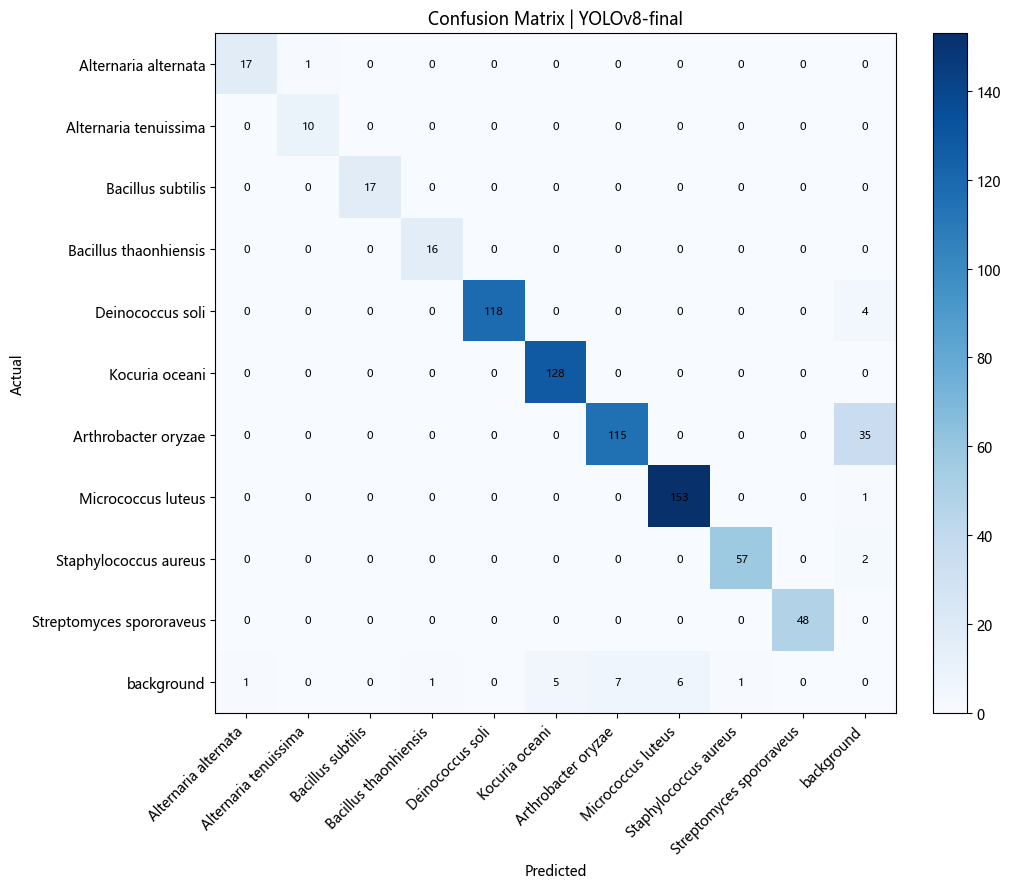

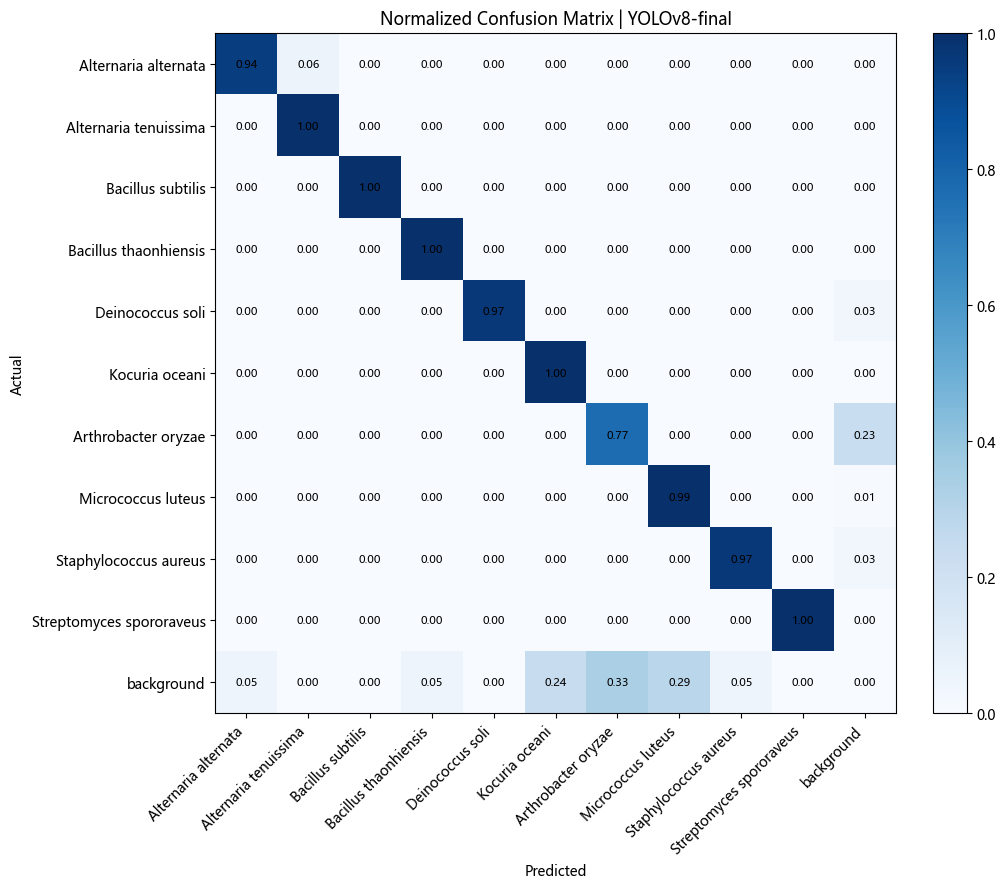

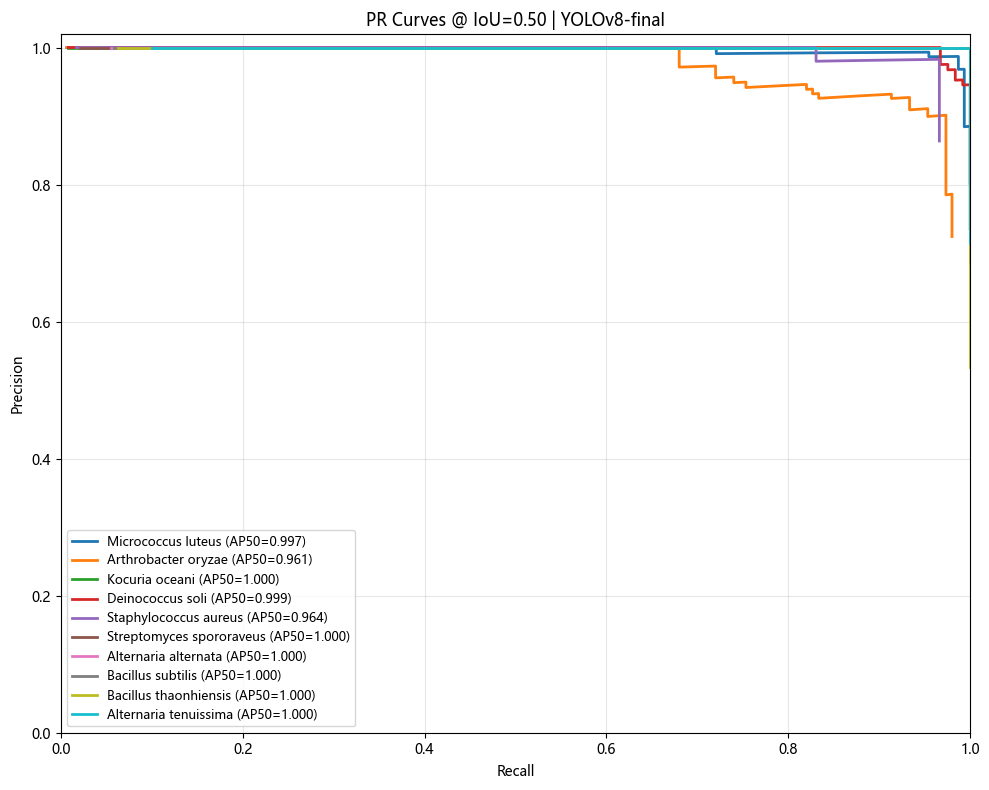

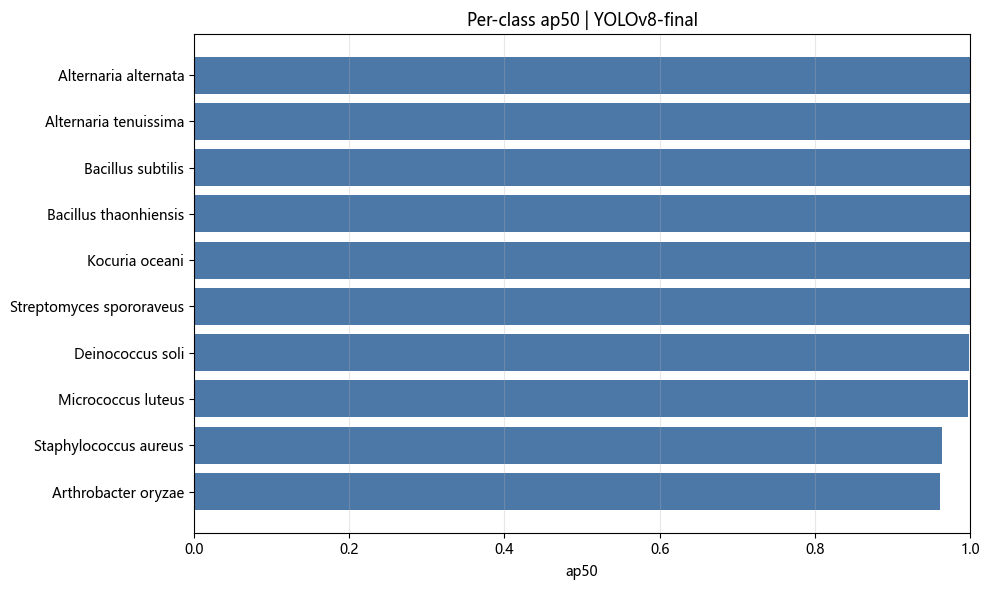

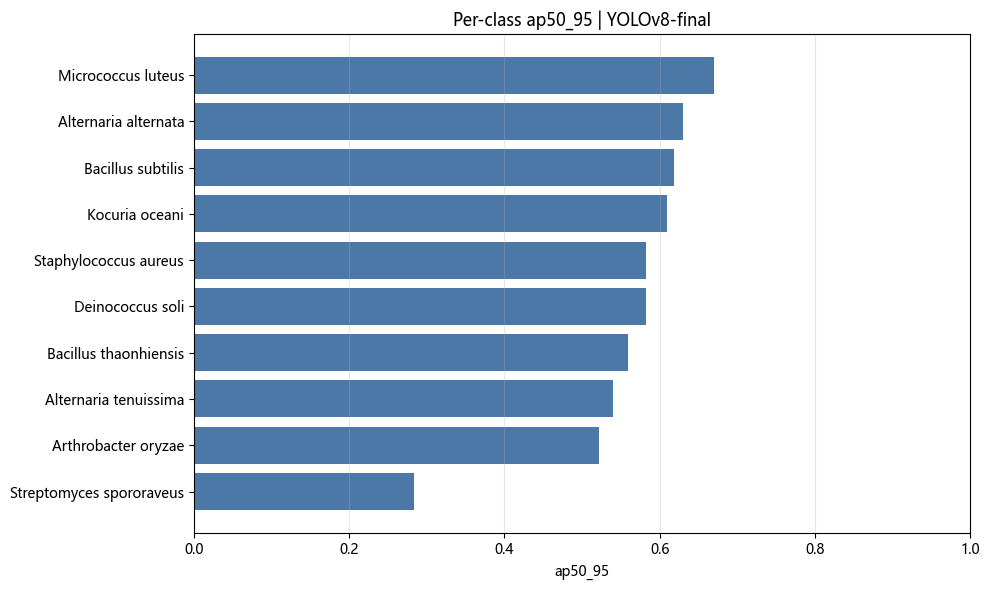

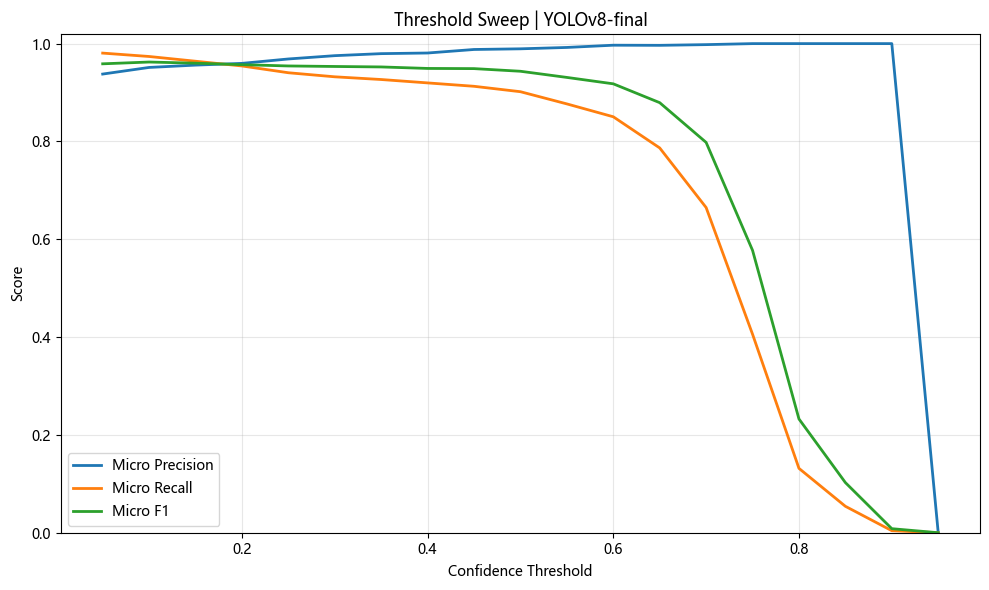

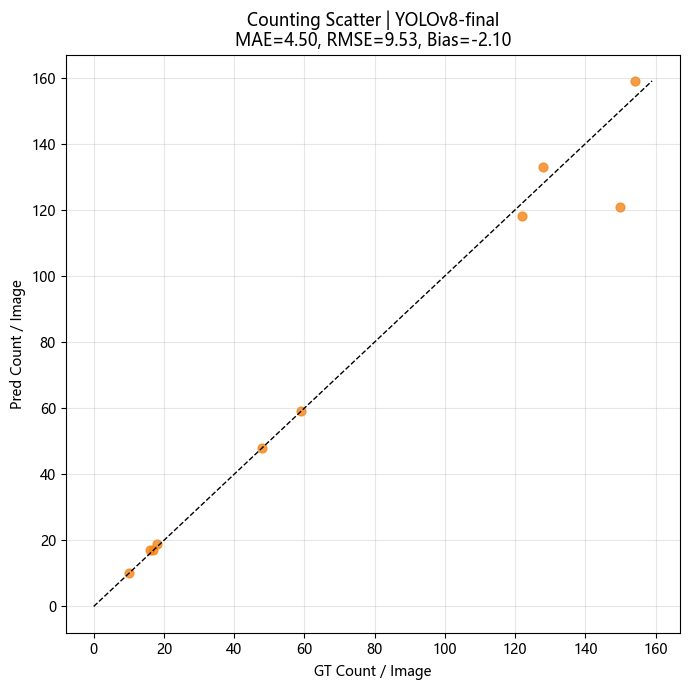

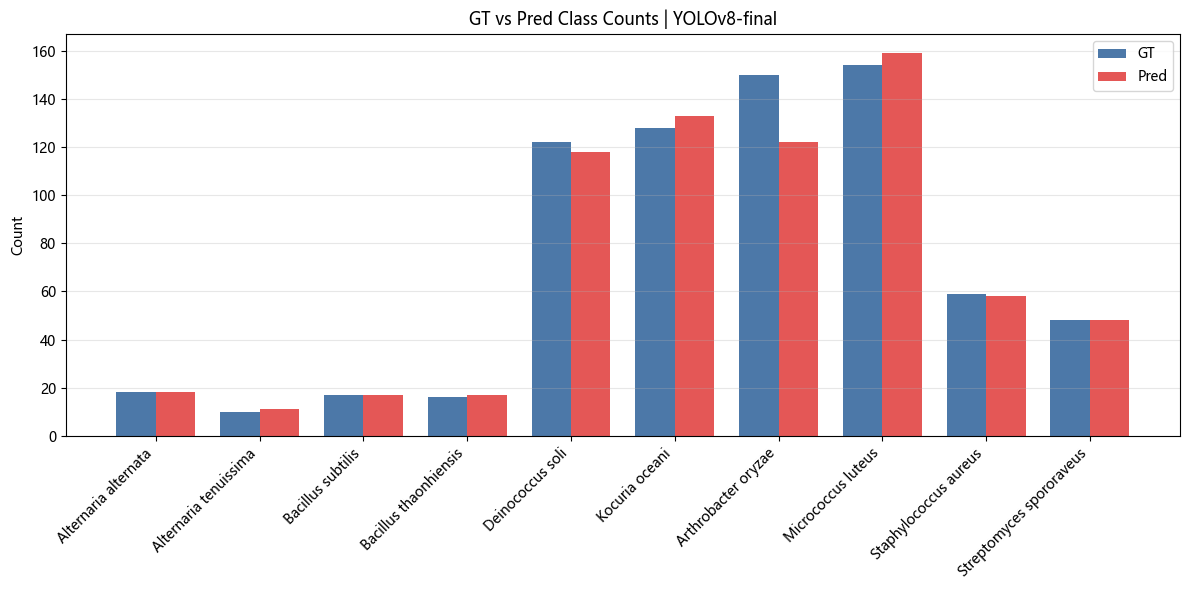

Evaluating: FasterRCNN-baseline
[FasterRCNN-baseline] 模型中存在但不在主类别列表中的类别: ['Actinomycetes']


Infer FasterRCNN-baseline: 100%|██████████| 10/10 [00:03<00:00,  2.77it/s]


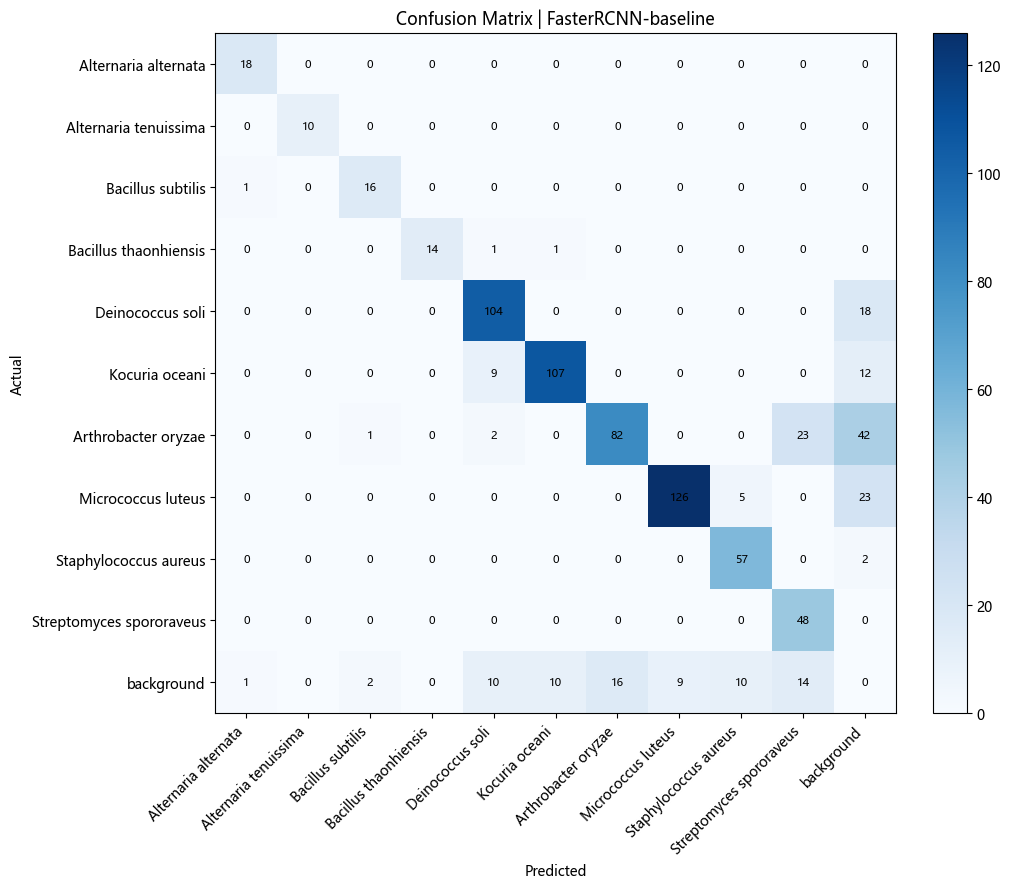

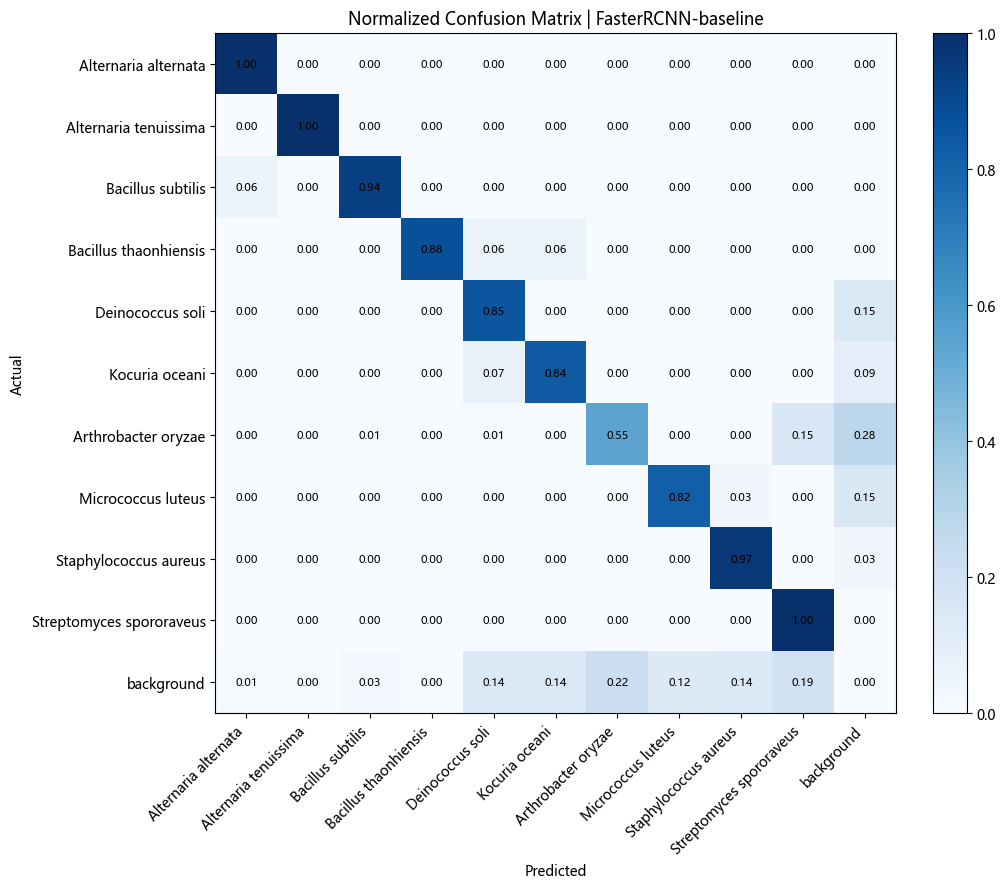

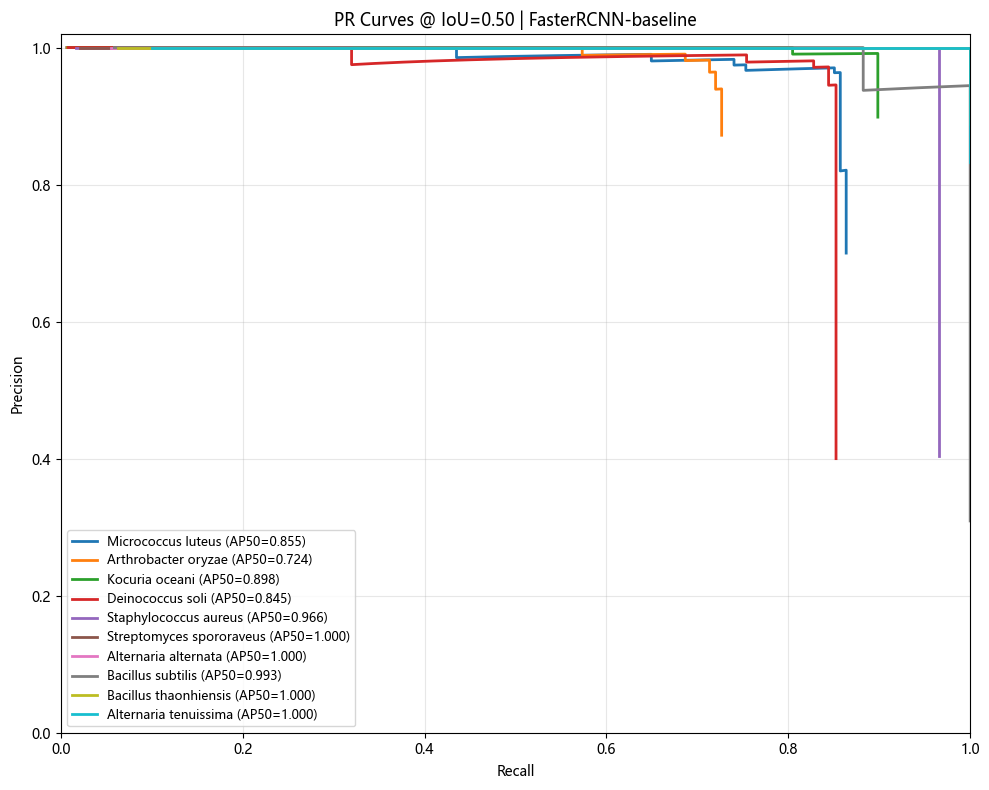

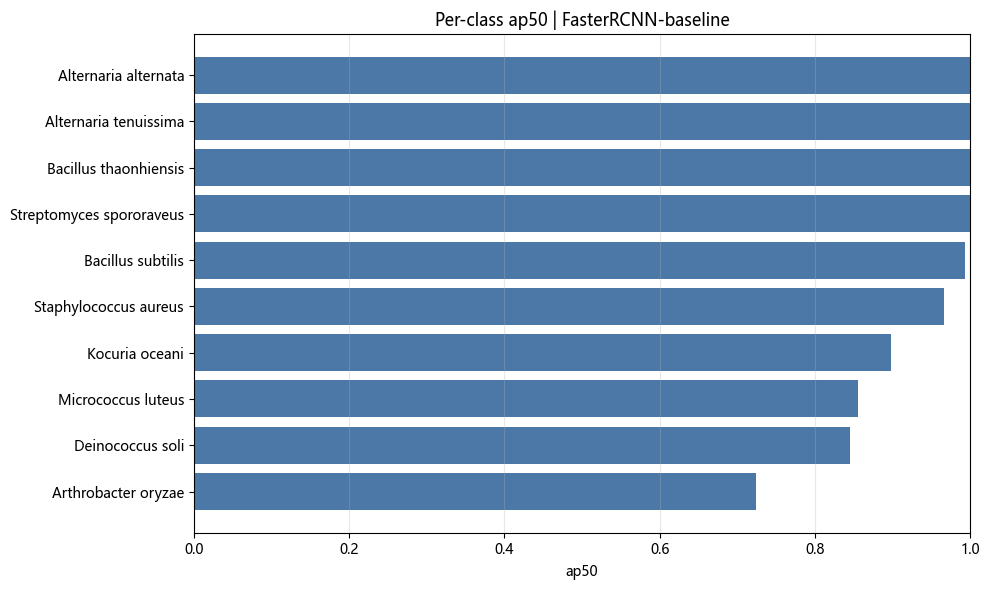

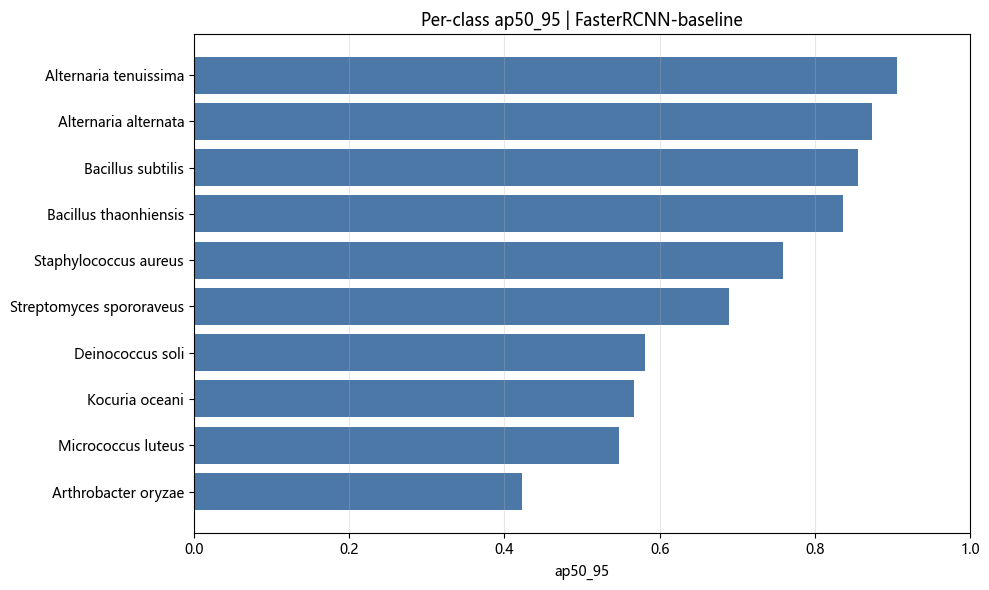

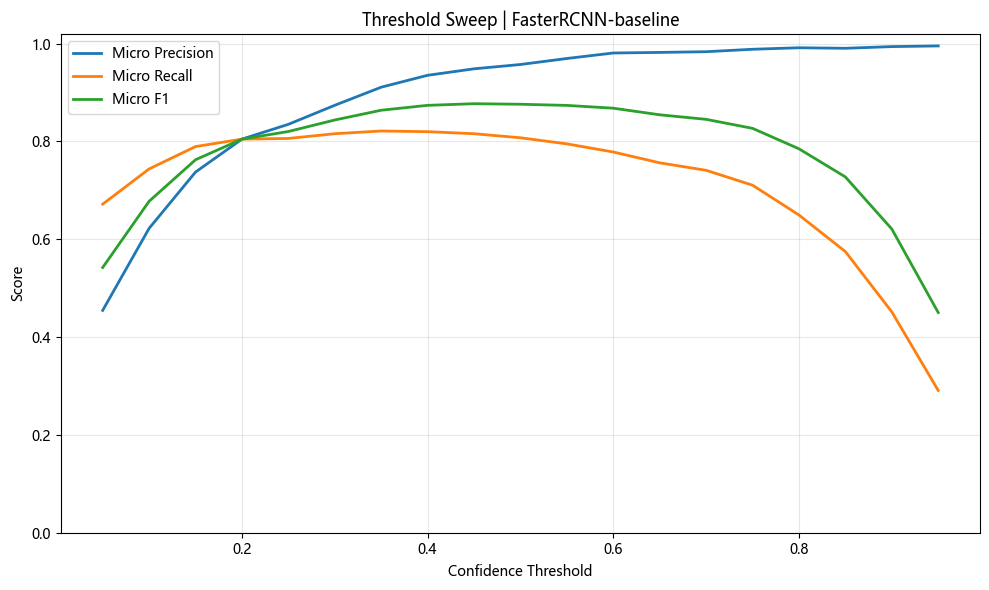

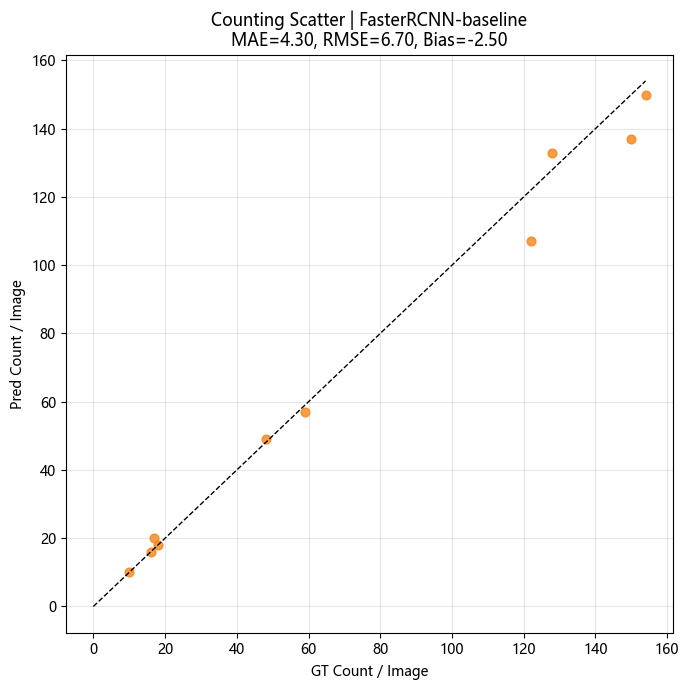

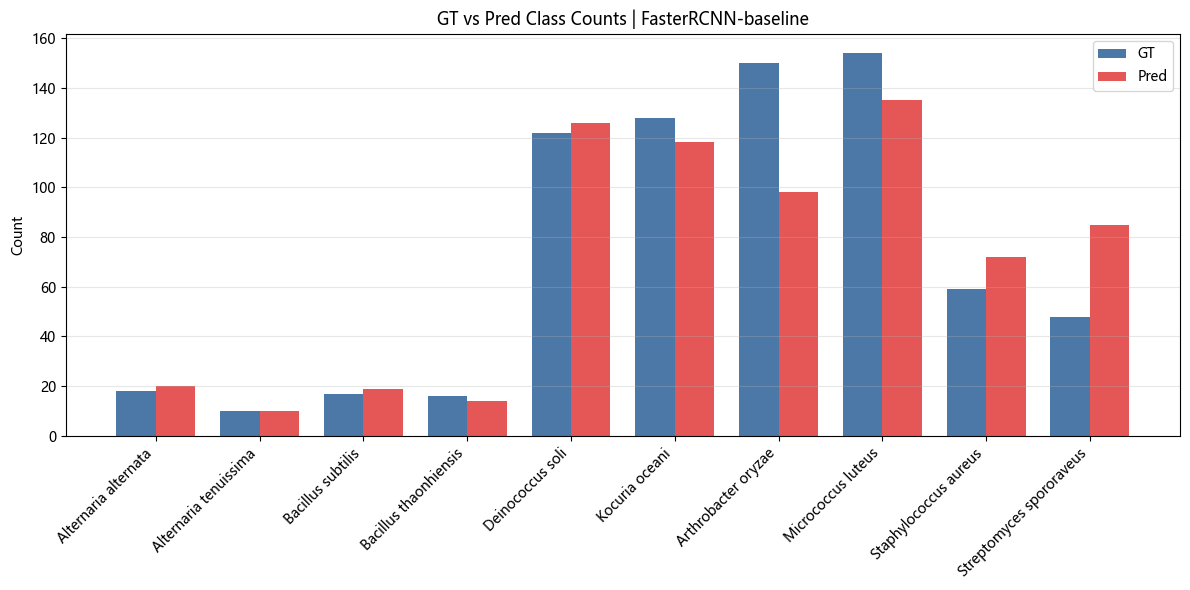

Evaluating: FasterRCNN-manual
[FasterRCNN-manual] 模型中存在但不在主类别列表中的类别: ['Actinomycetes']


Infer FasterRCNN-manual: 100%|██████████| 10/10 [00:02<00:00,  3.47it/s]


[FasterRCNN-manual] 以下预测类别被忽略，因为不在主类别列表中: ['Actinomycetes']


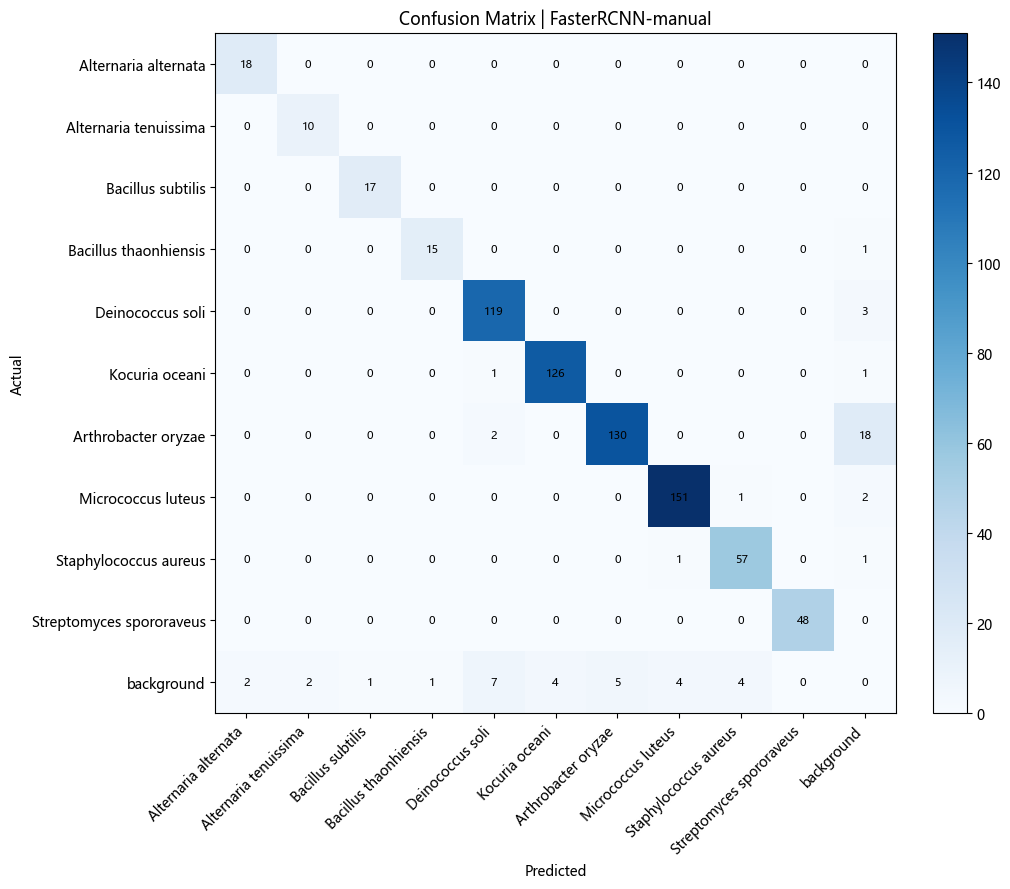

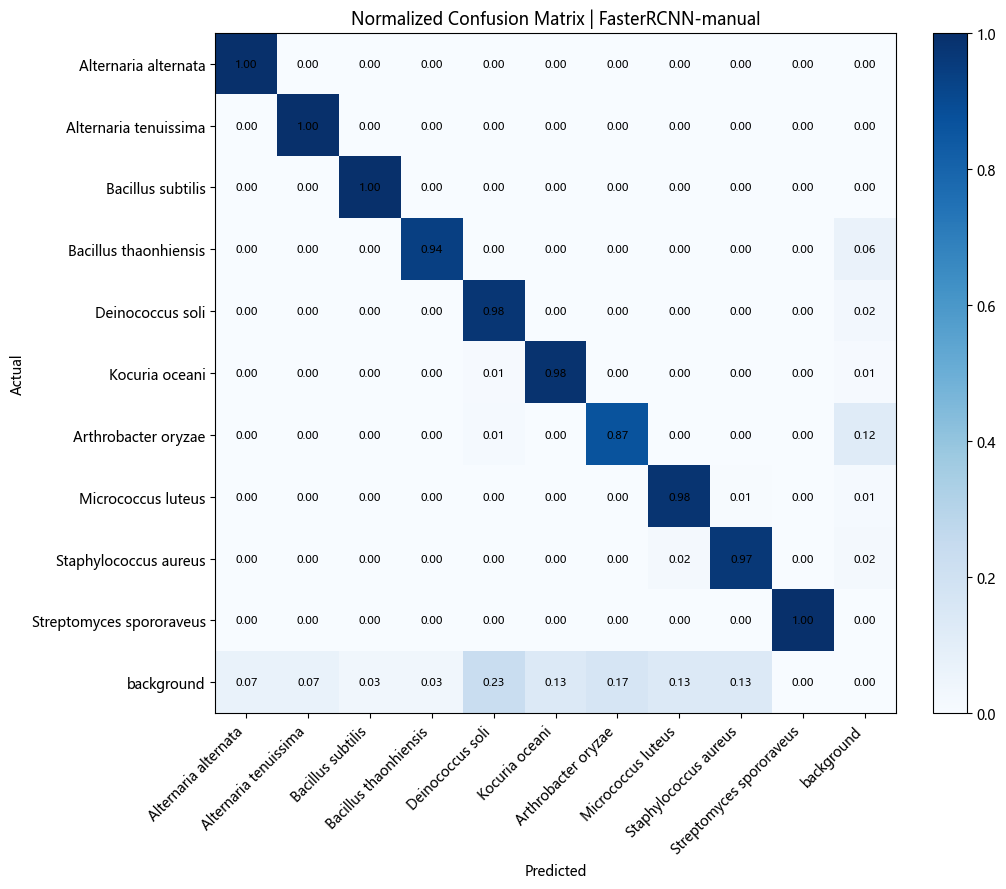

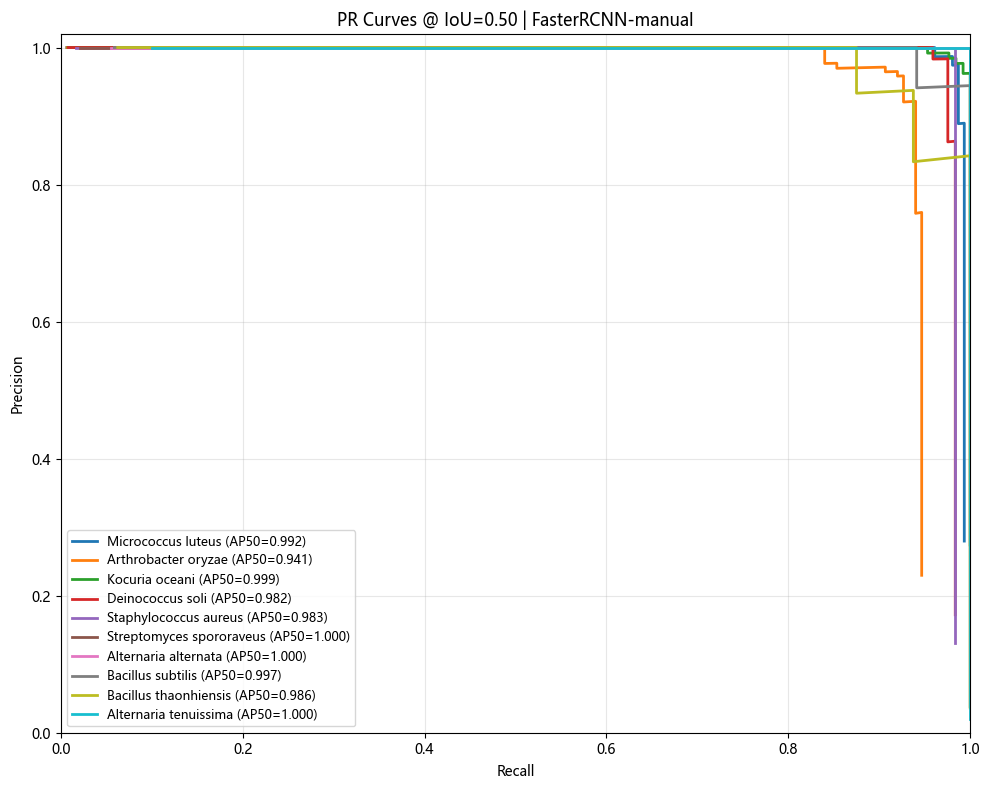

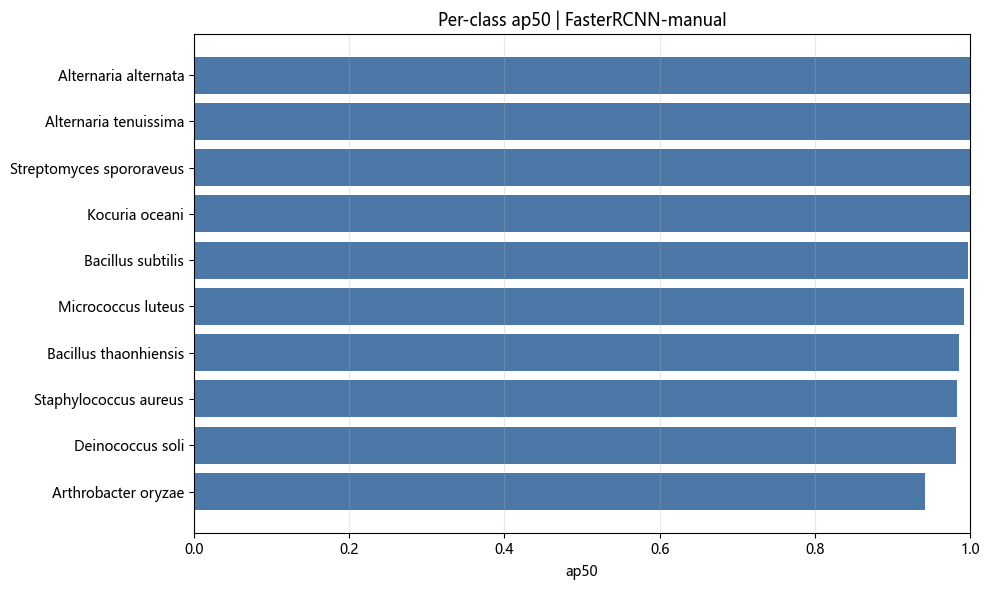

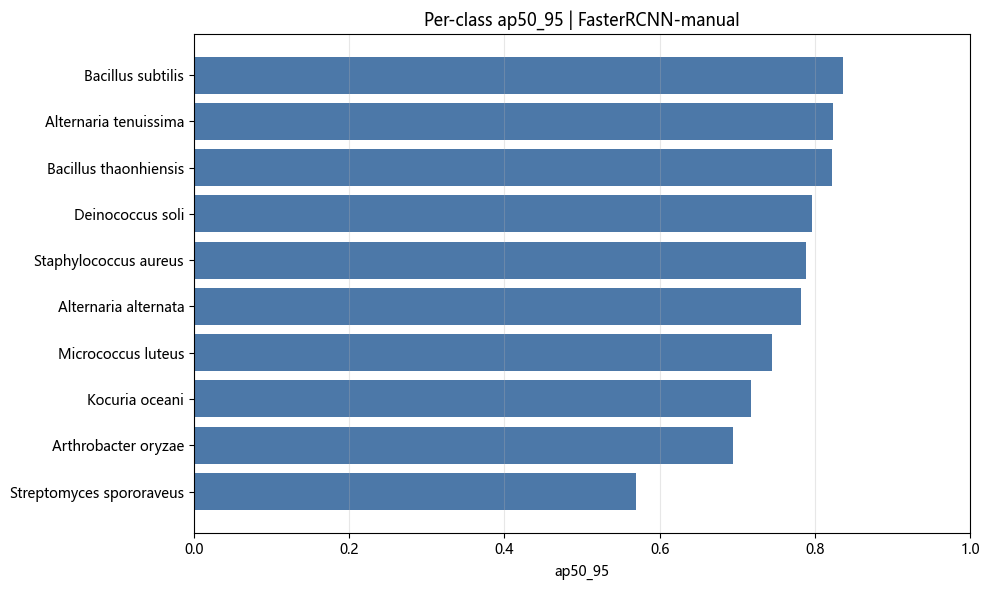

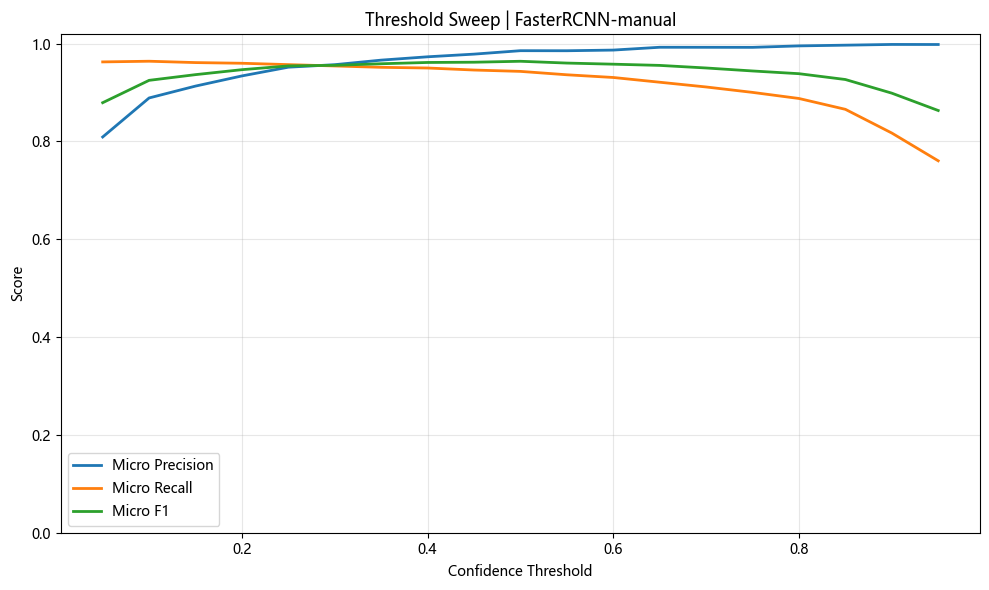

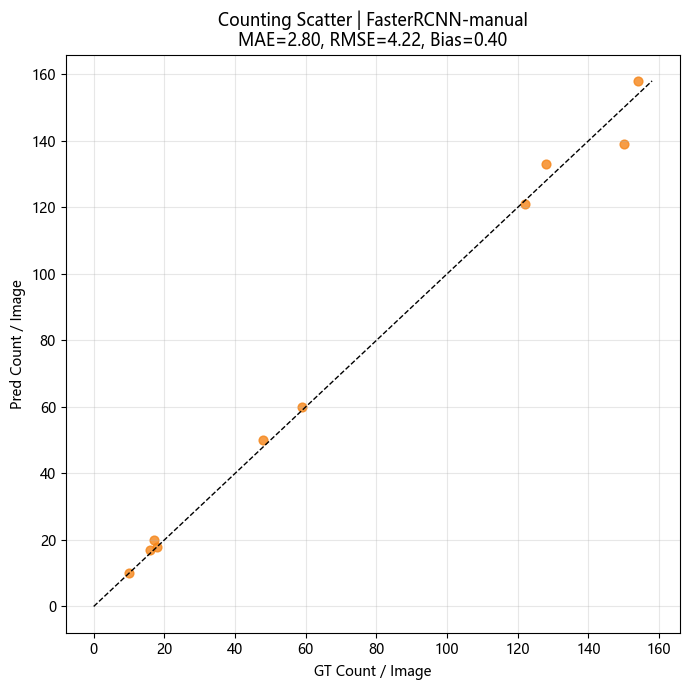

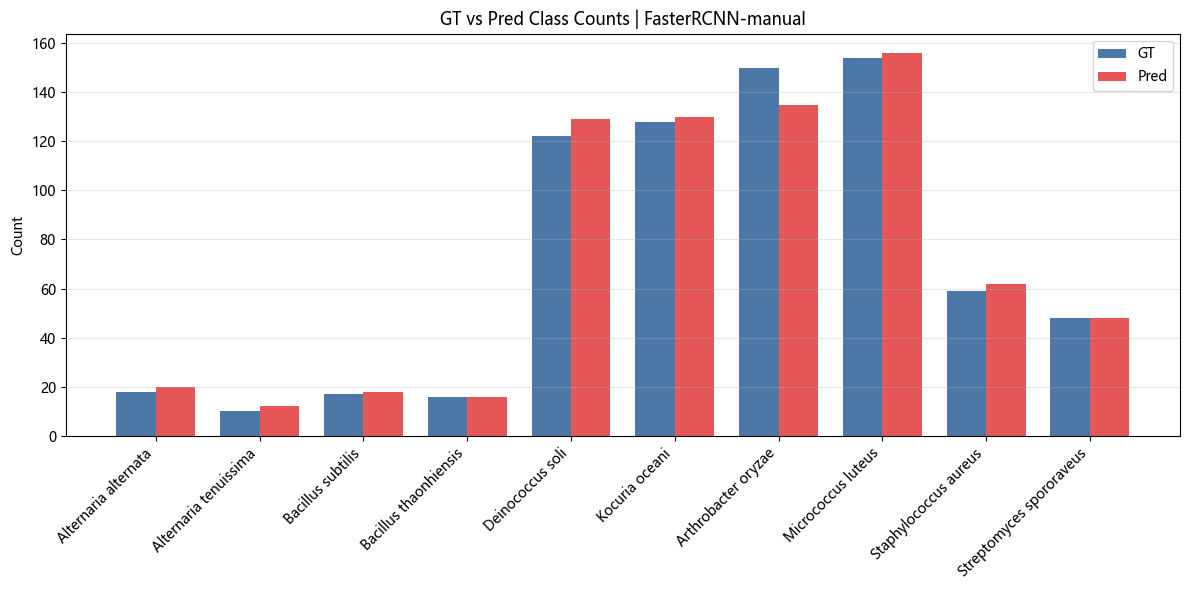

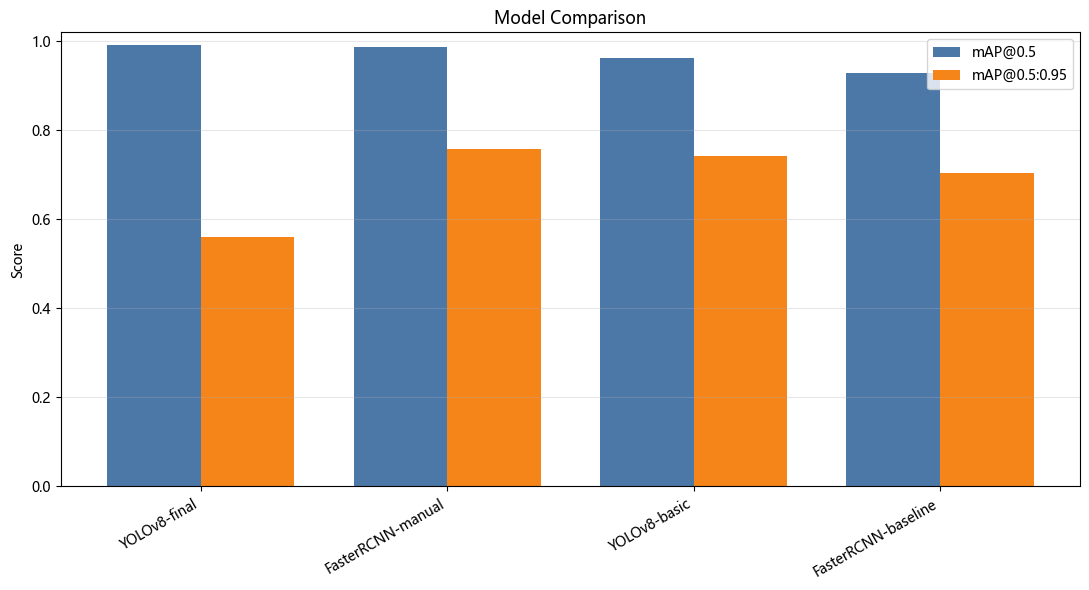

,model_name,mAP50,mAP50_95,micro_precision,micro_recall,micro_f1,macro_precision,macro_recall,macro_f1,count_mae,count_rmse,count_bias
0,YOLOv8-final,0.992037,0.559797,0.968616,0.940443,0.954322,0.964476,0.963793,0.962828,4.5,9.534149,-2.1
1,FasterRCNN-manual,0.988125,0.757527,0.951791,0.957064,0.954420,0.935726,0.971057,0.951896,2.8,4.219005,0.4
2,YOLOv8-basic,0.962470,0.741337,0.950995,0.860111,0.903273,0.953921,0.919814,0.923137,9.3,24.821362,-6.9
3,FasterRCNN-baseline,0.928242,0.703787,0.835007,0.806094,0.820296,0.860072,0.883552,0.860352,4.3,6.700746,-2.5


In [3]:
summary_df, all_results = run_full_evaluation(cfg)
display(summary_df)
